In [7]:
import numpy as np
import math

finding out slope of a function

In [8]:
a = 3.0
b = 2.0
c = 6.0

d = a * b + c
d

12.0

In [9]:
d1 = a * b + c
h = 0.000001
d2 = (a + h) * b + c
d2 - d1

2.000000000279556e-06

In [10]:
(d2 - d1) / h

2.000000000279556

In [11]:
d1 = a * b + c
h = 0.0000001
c += h
d2 = a * b + c
(d2 - d1) / h

1.0000000116860974

slope of a is 2 here. we also know mathematically (through derivation it would be b(ie =2.0))

## Neural Network Node Representation

In [12]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._children = _children
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        return Value(self.data + other.data, (self, other), '+')
    
    def __mul__(self, other):
        return Value(self.data * other.data, (self, other), '*')
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        return Value(t, (self,), 'tanh')
    

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

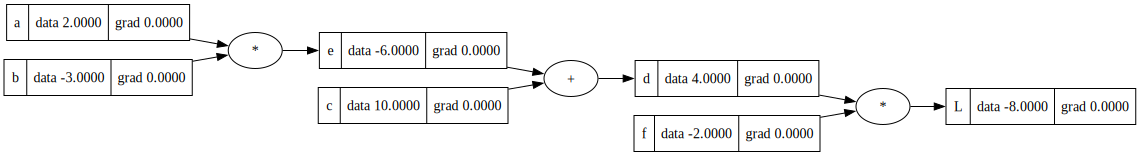

In [13]:
from graphviz import Digraph
def trace(root):
    """Build a set of nodes and edges to represent the graph of computations."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._children:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    """Draw a graph of computations using graphviz."""
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # LR = left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for simplicity, we'll just show the data in the node
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot
draw_dot(L)

In [16]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# w1, w2, b are the parameters of the model
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
b = Value(6.8813735870195432, label='b')
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

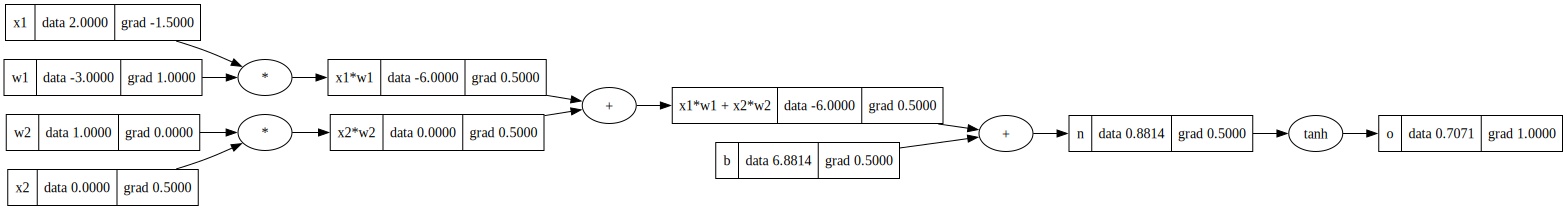

In [27]:
draw_dot(o)

In [26]:
x1.grad = w1.data * x2w2.grad
w1.grad = x1.data * x2w2.grad
x2.grad = w2.data * x1w1.grad
w2.grad = x2.data * x1w1.grad

In [24]:
x1w1.grad = 0.5
x2w2.grad = 0.5

In [22]:
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [20]:
n.grad = 0.5

In [18]:
o.grad = 1.0

In [19]:
# o = tanh(h)
# do/dn = 1 - o ** 2
1 - o.data ** 2

0.4999999999999999